# 04 — Model Training (VacFlow)

1. **Demand Forecasting (baseline)** — SMA vs Exponential Smoothing (จูน α)  
2. **Model Comparison** — RandomForest · XGBoost · LightGBM · Neural Network (MLP) จูนด้วย **Optuna**  
3. **Transportation Model** — Linear Programming หาแผนโอนย้ายต้นทุนต่ำสุด (Proposal §4.3)

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.optimize import linprog

ROOT = Path.cwd().parent if Path.cwd().name == 'notebook' else Path.cwd()
VAX = ROOT / 'data' / 'vaccine'
OUT = VAX / 'outputs'; OUT.mkdir(parents=True, exist_ok=True)
feat = pd.read_csv(VAX / 'features' / 'demand_features.csv', parse_dates=['date'])

In [2]:
# ── ทำให้ matplotlib แสดงภาษาไทยได้ (ลงทะเบียนฟอนต์ไทยที่เจอในเครื่อง) ──
import matplotlib.pyplot as plt
from matplotlib import font_manager
from pathlib import Path as _Path
_font_files = [
    'C:/Windows/Fonts/THSarabunNew.ttf', 'C:/Windows/Fonts/tahoma.ttf',
    'C:/Windows/Fonts/LeelawUI.ttf', 'C:/Windows/Fonts/angsa.ttf',
    '/usr/share/fonts/truetype/tlwg/Sarabun.ttf',
    '/usr/share/fonts/truetype/noto/NotoSansThai-Regular.ttf',
    '/Library/Fonts/Tahoma.ttf', '/System/Library/Fonts/Supplemental/Tahoma.ttf',
]
for _p in _font_files:
    if _Path(_p).exists():
        try: font_manager.fontManager.addfont(_p)
        except Exception: pass
_avail = {f.name for f in font_manager.fontManager.ttflist}
for _name in ['TH Sarabun New', 'Tahoma', 'Leelawadee UI', 'Sarabun', 'Angsana New', 'Noto Sans Thai']:
    if _name in _avail:
        plt.rcParams['font.family'] = _name
        break
plt.rcParams['axes.unicode_minus'] = False   # กันเครื่องหมายลบเพี้ยน
print('matplotlib font ->', plt.rcParams['font.family'])

matplotlib font -> ['Tahoma']


## 1) Demand Forecasting — จูน α ของ Exponential Smoothing

แบ่ง train/test ตามเวลา (80/20) แล้ววัด RMSE ของ SMA-7 เทียบกับ ES ที่ α ต่าง ๆ

In [3]:
def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

def es_forecast(series, alpha):
    f = series.iloc[0]
    out = []
    for t in range(len(series)):
        out.append(f)
        f = alpha * series.iloc[t] + (1 - alpha) * f
    return np.array(out)

alphas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.7]
CV_THR = 0.6   # §math: ความผันผวนสูง (CV = std/mean > เกณฑ์) = สภาวะวิกฤต -> ES · ปกติ -> SMA
results = []
for (hid, pid), g in feat.groupby(['hospital_id', 'product_id']):
    g = g.sort_values('date'); cut = int(len(g) * 0.8)
    train, test = g.iloc[:cut], g.iloc[cut:]
    mu = train['demand'].mean()
    cv = float(train['demand'].std() / mu) if mu > 0 else 0.0
    scenario = 'crisis' if cv > CV_THR else 'normal'      # ตรวจสภาวะจากความผันผวน
    method = 'ES' if scenario == 'crisis' else 'SMA'
    sma_rmse = rmse(test['demand'], test['sma_7'])
    best_a, best_r = None, np.inf
    for a in alphas:
        pred = es_forecast(g['demand'], a)[cut:]
        r = rmse(test['demand'], pred)
        if r < best_r: best_a, best_r = a, r
    # พยากรณ์ดีมานด์ "รอบถัดไป/วัน" ตามวิธีที่เลือก → ป้อนกลับเข้า reorder/transship/alert (ปิดวงจร ML)
    sma_next = float(g['demand'].tail(7).mean())
    es_next = float(best_a * g['demand'].iloc[-1] + (1 - best_a) * es_forecast(g['demand'], best_a)[-1])
    forecast_daily = round(max(0.0, es_next if method == 'ES' else sma_next), 2)
    results.append({'hospital_id': hid, 'product_id': pid,
                    'sma7_rmse': round(sma_rmse, 2), 'best_alpha': best_a,
                    'es_rmse': round(best_r, 2), 'cv': round(cv, 2), 'scenario': scenario,
                    'method': method, 'forecast_daily': forecast_daily,   # ← ใช้จริงใน webapp
                    'winner': 'ES' if best_r < sma_rmse else 'SMA'})       # เทียบ RMSE (อ้างอิง)
fc = pd.DataFrame(results)
print('scenario:', fc['scenario'].value_counts().to_dict(),
      '| forecast_daily เฉลี่ย:', round(fc['forecast_daily'].mean(), 2))
fc

scenario: {'normal': 1797, 'crisis': 166} | forecast_daily เฉลี่ย: 17.96


,hospital_id,product_id,sma7_rmse,best_alpha,es_rmse,cv,scenario,method,forecast_daily,winner
0,HOSP_001,VAX_J07AE01_051,2.75,0.1,2.82,0.54,normal,SMA,8.00,SMA
1,HOSP_001,VAX_J07AE01_052,6.26,0.1,6.39,0.51,normal,SMA,19.57,SMA
2,HOSP_001,VAX_J07AE_099,5.74,0.1,5.86,0.44,normal,SMA,15.00,SMA
3,HOSP_001,VAX_J07AG51_053,6.77,0.1,6.94,0.58,normal,SMA,19.14,SMA
4,HOSP_001,VAX_J07AH08_101,2.57,0.1,2.67,0.53,normal,SMA,7.43,SMA
...,...,...,...,...,...,...,...,...,...,...
1958,HOSP_013,VAX_J07CA09_148,7.31,0.7,7.12,0.51,normal,SMA,15.86,ES
1959,HOSP_013,VAX_J07CA11_149,5.05,0.2,5.52,0.59,normal,SMA,16.00,SMA
1960,HOSP_013,VAX_J07CA11_150,5.77,0.1,6.30,0.56,normal,SMA,18.43,SMA
1961,HOSP_013,VAX_J07CA11_151,6.91,0.1,7.11,0.41,normal,SMA,21.00,SMA


In [4]:
fc.to_csv(OUT / 'forecast_model_selection.csv', index=False, encoding='utf-8-sig')
# demand_forecast.csv — ดีมานด์พยากรณ์/วัน ต่อ (รพ.×product) ที่ webapp ใช้จริง (reorder/transship/alert)
fc[['hospital_id', 'product_id', 'method', 'forecast_daily']].to_csv(
    OUT / 'demand_forecast.csv', index=False, encoding='utf-8-sig')
print('mean SMA RMSE:', round(fc['sma7_rmse'].mean(), 2),
      '| mean ES RMSE:', round(fc['es_rmse'].mean(), 2),
      '| saved demand_forecast.csv:', len(fc), 'rows')

mean SMA RMSE: 7.91 | mean ES RMSE: 7.73 | saved demand_forecast.csv: 1963 rows


## 2) เปรียบเทียบโมเดล ML + Optuna

พยากรณ์ดีมานด์รายวันแบบ **global model** จากฟีเจอร์ (lag/rolling/SMA/ES + สาขา/ผลิตภัณฑ์) 
เทียบ **RandomForest · XGBoost · LightGBM · Neural Network (MLP)** จูน hyperparameter ด้วย **Optuna** 
เทียบกับ baseline SMA-7  · วัดด้วย MAE / RMSE / R²

In [5]:
# (ถ้ายังไม่มี lib) %pip install -q scikit-learn xgboost lightgbm optuna
import warnings; warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)
try:
    from xgboost import XGBRegressor; HAS_XGB = True
except Exception: HAS_XGB = False
try:
    from lightgbm import LGBMRegressor; HAS_LGB = True
except Exception: HAS_LGB = False

BASE_FEATS = ['lag_1','lag_7','lag_14','sma_7','sma_14','roll_std_7','es_0.4','dow','is_weekend']
# exogenous (ประชากร/อายุ/ไข้หวัดใหญ่/อากาศ) จาก notebook 03 — อ่านจาก manifest ถ้ามี
_manifest = VAX / 'features' / 'exogenous_features.txt'
EXOG = _manifest.read_text(encoding='utf-8').split() if _manifest.exists() else []
EXOG = [c for c in EXOG if c in feat.columns]                 # ใช้เฉพาะที่มีจริงในไฟล์ฟีเจอร์
FEATS = BASE_FEATS + EXOG
print('features:', len(FEATS), '| exogenous:', EXOG or '(ไม่มี — รัน notebook 03 ใหม่)')
df = feat.sort_values('date').reset_index(drop=True)
X = pd.concat([df[FEATS], pd.get_dummies(df[['hospital_id','product_id']]).astype(int)], axis=1)
y = df['demand'].to_numpy()
# split ตามเวลา: train 70% · valid 10% (จูน Optuna) · test 20%
n = len(df); i_tr, i_va = int(n * 0.7), int(n * 0.8)
Xtr, ytr = X.iloc[:i_tr], y[:i_tr]
Xva, yva = X.iloc[i_tr:i_va], y[i_tr:i_va]
Xte, yte = X.iloc[i_va:], y[i_va:]
sma_te = df['sma_7'].to_numpy()[i_va:]      # baseline เทียบ
def rmse(a, b): return float(np.sqrt(mean_squared_error(a, b)))
print(f'train {len(Xtr)} · valid {len(Xva)} · test {len(Xte)} · features {X.shape[1]}')

features: 18 | exogenous: ['log_pop', 'frac_u5', 'frac_60p', 'ili_rate', 'rainy_season', 'temp_c', 'small_hosp', 'zero_demand_small', 'ili_reported']
train 228100 · valid 32586 · test 65172 · features 182


In [6]:
# ── GPU acceleration (XGBoost / LightGBM) — probe จริงก่อนเปิด ไม่งั้น fallback CPU ──
#    RandomForest/MLP ของ sklearn เป็น CPU-only จึงไม่แตะ (จะใช้ GPU ต้องเปลี่ยนไป cuML)
_Xp, _yp = np.random.rand(16, 3), (np.arange(16) % 4).astype(float)   # ชุดจิ๋วไว้ทดสอบฟิตบน GPU

def _probe_xgb_gpu():
    if not HAS_XGB:
        return {}
    try:  # xgboost >= 2.0 : device='cuda' + tree_method='hist'
        XGBRegressor(n_estimators=4, device='cuda', tree_method='hist',
                     verbosity=0).fit(_Xp, _yp)
        print('[gpu] XGBoost  -> CUDA ✅')
        return {'device': 'cuda', 'tree_method': 'hist'}
    except Exception as e:
        print('[gpu] XGBoost  -> CPU (', str(e).splitlines()[0][:70], ')')
        return {'tree_method': 'hist'}

def _probe_lgb_gpu():
    if not HAS_LGB:
        return {}
    try:  # lightgbm ต้องเป็น GPU build (pip wheel ปกติเป็น CPU-only) -> มักตกมา CPU
        LGBMRegressor(n_estimators=4, device_type='gpu', verbose=-1).fit(_Xp, _yp)
        print('[gpu] LightGBM -> GPU ✅')
        return {'device_type': 'gpu'}
    except Exception as e:
        print('[gpu] LightGBM -> CPU (', str(e).splitlines()[0][:70], ')')
        return {}

XGB_GPU = _probe_xgb_gpu()   # spread เข้า constructor ของ XGBoost ทุกที่
LGB_GPU = _probe_lgb_gpu()   # spread เข้า constructor ของ LightGBM ทุกที่
print('XGB params:', XGB_GPU, '| LGB params:', LGB_GPU)

[gpu] XGBoost  -> CUDA ✅
[gpu] LightGBM -> GPU ✅
XGB params: {'device': 'cuda', 'tree_method': 'hist'} | LGB params: {'device_type': 'gpu'}


In [7]:
import os
# nightly (retrainer) ตั้ง env เพื่อเทรนเร็วและใช้ GPU เป็นหลัก:
#   VACFLOW_MODELS=XGBoost   → เทรนเฉพาะ XGBoost (รันบน CUDA) · VACFLOW_N_TRIALS=จำนวน trial
N_TRIALS = int(os.environ.get('VACFLOW_N_TRIALS', 25))
def _model(name, t):
    if name == 'RandomForest':
        return RandomForestRegressor(
            n_estimators=t.suggest_int('n_estimators', 100, 500),
            max_depth=t.suggest_int('max_depth', 3, 16),
            min_samples_leaf=t.suggest_int('min_samples_leaf', 1, 8),
            max_features=t.suggest_float('max_features', 0.4, 1.0),
            n_jobs=-1, random_state=42)
    if name == 'XGBoost':
        return XGBRegressor(
            n_estimators=t.suggest_int('n_estimators', 100, 600),
            max_depth=t.suggest_int('max_depth', 3, 10),
            learning_rate=t.suggest_float('learning_rate', 0.01, 0.3, log=True),
            subsample=t.suggest_float('subsample', 0.6, 1.0),
            colsample_bytree=t.suggest_float('colsample_bytree', 0.6, 1.0),
            n_jobs=-1, random_state=42, verbosity=0, **XGB_GPU)   # GPU ถ้า probe ผ่าน
    if name == 'LightGBM':
        return LGBMRegressor(
            n_estimators=t.suggest_int('n_estimators', 100, 600),
            num_leaves=t.suggest_int('num_leaves', 15, 128),
            learning_rate=t.suggest_float('learning_rate', 0.01, 0.3, log=True),
            subsample=t.suggest_float('subsample', 0.6, 1.0),
            min_child_samples=t.suggest_int('min_child_samples', 5, 50),
            n_jobs=-1, random_state=42, verbose=-1, **LGB_GPU)    # GPU ถ้า probe ผ่าน
    # Neural Network (MLP)
    hidden = t.suggest_categorical('hidden', ['64', '64,32', '128,64'])
    return make_pipeline(StandardScaler(), MLPRegressor(
        hidden_layer_sizes=tuple(int(x) for x in hidden.split(',')),
        alpha=t.suggest_float('alpha', 1e-5, 1e-1, log=True),
        learning_rate_init=t.suggest_float('lr', 1e-4, 1e-2, log=True),
        max_iter=300, early_stopping=True, random_state=42))

def tune(name):
    def objective(t):
        m = _model(name, t); m.fit(Xtr, ytr)
        return rmse(yva, m.predict(Xva))
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    return study.best_params, study.best_value

# _AVAILABLE = ['RandomForest'] + (['XGBoost'] if HAS_XGB else []) + \
#              (['LightGBM'] if HAS_LGB else []) + ['NeuralNet']
_AVAILABLE = (['XGBoost'] if HAS_XGB else []) + \
             (['LightGBM'] if HAS_LGB else [])
# เลือกโมเดลตาม env (nightly: VACFLOW_MODELS=XGBoost) — ว่าง = เทรนครบทุกตัว (รันมือ)
_sel = [m.strip() for m in os.environ.get('VACFLOW_MODELS', '').split(',') if m.strip()]
MODELS = [m for m in _AVAILABLE if m in _sel] or _AVAILABLE
print('models to train:', MODELS, '| trials:', N_TRIALS)
best = {}
for name in MODELS:
    params, val = tune(name)
    best[name] = params
    print(f'{name:13s} best valid RMSE {val:6.3f}  {params}')

models to train: ['XGBoost', 'LightGBM'] | trials: 25
XGBoost       best valid RMSE  5.619  {'n_estimators': 255, 'max_depth': 9, 'learning_rate': 0.04509484184955547, 'subsample': 0.8913130978367605, 'colsample_bytree': 0.874052531669745}
LightGBM      best valid RMSE  5.635  {'n_estimators': 526, 'num_leaves': 92, 'learning_rate': 0.029033399006694303, 'subsample': 0.6628797655590637, 'min_child_samples': 33}


In [8]:
# refit ด้วย train+valid แล้ววัดบน test (เทียบ baseline SMA-7)
def build(name, p):
    if name == 'NeuralNet':
        h = tuple(int(x) for x in p['hidden'].split(','))
        return make_pipeline(StandardScaler(), MLPRegressor(
            hidden_layer_sizes=h, alpha=p['alpha'], learning_rate_init=p['lr'],
            max_iter=300, early_stopping=True, random_state=42))
    cls = {'RandomForest': RandomForestRegressor, 'XGBoost': XGBRegressor,
           'LightGBM': LGBMRegressor}[name]
    kw = dict(p, n_jobs=-1, random_state=42)
    if name == 'XGBoost': kw.update(verbosity=0, **XGB_GPU)   # GPU ถ้า probe ผ่าน
    if name == 'LightGBM': kw.update(verbose=-1, **LGB_GPU)   # GPU ถ้า probe ผ่าน
    return cls(**kw)

Xall = pd.concat([Xtr, Xva]); yall = np.concatenate([ytr, yva])
rows = [{'model': 'SMA-7 (baseline)',
         'MAE': round(mean_absolute_error(yte, sma_te), 2),
         'RMSE': round(rmse(yte, sma_te), 2),
         'R2': round(r2_score(yte, sma_te), 3)}]
for name in MODELS:
    m = build(name, best[name]); m.fit(Xall, yall); pred = m.predict(Xte)
    rows.append({'model': name,
                 'MAE': round(mean_absolute_error(yte, pred), 2),
                 'RMSE': round(rmse(yte, pred), 2),
                 'R2': round(r2_score(yte, pred), 3)})
cmp = pd.DataFrame(rows).sort_values('RMSE').reset_index(drop=True)
cmp.to_csv(OUT / 'model_comparison.csv', index=False, encoding='utf-8-sig')
winner = cmp.iloc[0]['model']
print('>>> best model (lowest RMSE):', winner)
cmp

>>> best model (lowest RMSE): LightGBM


,model,MAE,RMSE,R2
0,LightGBM,3.36,5.43,0.780
1,XGBoost,3.35,5.44,0.779
2,SMA-7 (baseline),6.33,9.09,0.383


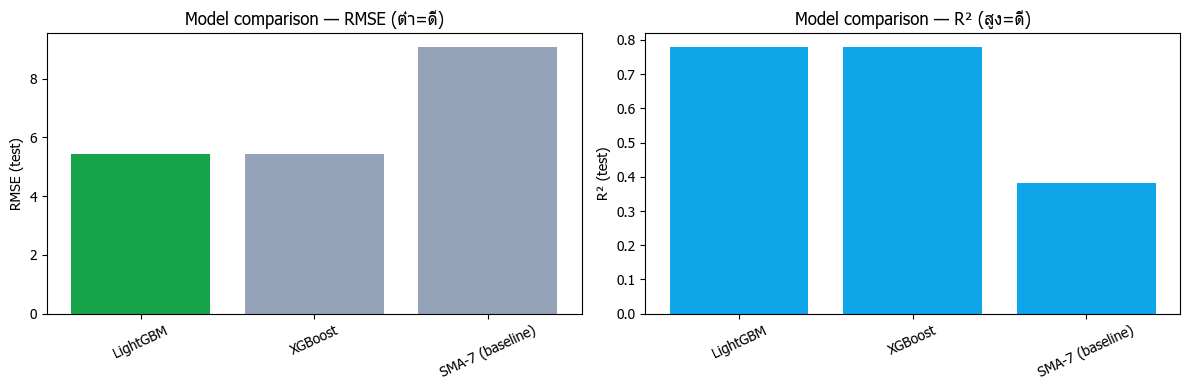

In [9]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(cmp['model'], cmp['RMSE'],
          color=['#16a34a' if m == winner else '#94a3b8' for m in cmp['model']])
ax[0].set_ylabel('RMSE (test)'); ax[0].set_title('Model comparison — RMSE (ต่ำ=ดี)')
ax[0].tick_params(axis='x', rotation=25)
ax[1].bar(cmp['model'], cmp['R2'], color='#0ea5e9')
ax[1].set_ylabel('R² (test)'); ax[1].set_title('Model comparison — R² (สูง=ดี)')
ax[1].tick_params(axis='x', rotation=25)
plt.tight_layout(); plt.show()

## 3) Transportation Model (Lateral Transshipment)

Minimize `Z = ΣΣ c(i,j)·x(i,j)`  s.t. `Σ_j x(i,j) ≤ S(i)` (ต้นทาง), 
`Σ_i x(i,j) ≥ D(j)` (ปลายทาง), `x ≥ 0`  
โดย `c(i,j)` = ระยะทาง × transport_rate · `S(i)` = โดสเสี่ยงหมดอายุ (สถานะแดง ที่ขนส่งได้) · 
`D(j)` = ดีมานด์ที่ยังขาด

In [10]:
import sys
from numpy import radians, sin, cos, arccos, clip
sys.path.insert(0, str(ROOT / 'vaccine-engine'))   # ใช้ engine จริง (เลิก reimplement)
from modules import matching_engine as ME           # screen_at_risk + solve_transport (ตรงสูตร §3.2.2)

master = pd.read_csv(ROOT / 'data' / 'hospitals' / 'hospital_master.csv')
branches = pd.read_csv(VAX / 'vaccine_branches.csv')
vials = pd.read_csv(VAX / 'clean' / 'vaccine_vial_clean.csv')
vials['effective_expiry'] = pd.to_datetime(vials['effective_expiry'], utc=True, format='ISO8601')
BR = list(branches['hospital_id'])
loc = master.set_index('hospital_id').loc[BR, ['latitude', 'longitude']]
rate = branches.set_index('hospital_id')['transport_rate']

def haversine(a, b):
    la1, lo1, la2, lo2 = map(radians, [loc.loc[a, 'latitude'], loc.loc[a, 'longitude'],
                                       loc.loc[b, 'latitude'], loc.loc[b, 'longitude']])
    return 6371 * arccos(clip(sin(la1) * sin(la2) + cos(la1) * cos(la2) * cos(lo2 - lo1), -1, 1))

# ระยะทาง "ตามถนนจริง" (precompute จาก OSRM: scripts/compute_road_distance.py) — fallback haversine
_dm_path = ROOT / 'data' / 'hospitals' / 'distance_matrix.csv'
_DM = ({(r.from_hospital, r.to_hospital): r.distance_km
        for r in pd.read_csv(_dm_path).itertuples(index=False)} if _dm_path.exists() else {})
def road_km(a, b):
    return _DM.get((a, b), haversine(a, b))
print('distance source:', 'OSRM (ถนนจริง)' if _DM else 'haversine (ไม่พบ distance_matrix.csv)')

now = pd.Timestamp('2026-06-26T08:00:00+07:00')
vials['days_remaining'] = (vials['effective_expiry'] - now).dt.total_seconds() / 86400

# ── เลือกผลิตภัณฑ์อัตโนมัติ: ของเสี่ยง (≤14 วัน, ขนส่งได้) รวมมากสุด + มีดีมานด์รองรับ ──
demand_prods = set(feat['product_id'].unique())
risk_all = vials[(vials.hospital_id.isin(BR)) & (vials.state != 'OPENED')
                 & (vials.days_remaining <= 14)]
risk_by_prod = risk_all.groupby('product_id')['doses_remaining'].sum()
risk_by_prod = risk_by_prod[risk_by_prod.index.isin(demand_prods) & (risk_by_prod > 0)]
if len(risk_by_prod):
    pid = risk_by_prod.idxmax()
    print(f'เลือกผลิตภัณฑ์อัตโนมัติ (เสี่ยงหมดอายุมากสุด): {pid} '
          f'· รวม {risk_by_prod.max():.0f} โดส · มีของเสี่ยง {len(risk_by_prod)} ผลิตภัณฑ์')
else:
    pid = feat.groupby('product_id')['demand'].mean().idxmax()
    print(f'ไม่มีของเสี่ยง -> เลือกผลิตภัณฑ์ดีมานด์สูงสุดมาเดโม: {pid}')

# demand ปลายทาง = ดีมานด์เฉลี่ย 7 วันล่าสุด (ใช้เป็น usage_rate ของ screen_at_risk ด้วย)
recent = feat[(feat.product_id == pid) & (feat.date >= feat.date.max() - pd.Timedelta(days=7))]
demand_j = recent.groupby('hospital_id')['demand'].mean().reindex(BR, fill_value=0).round()
usage_rate = demand_j.to_dict()

# ── screen_at_risk (engine §3.2.2): ระบายเฉพาะสาขาที่ "บริโภคต่ำกว่าเกณฑ์" (median) ──
thr = float(demand_j[demand_j > 0].median()) if (demand_j > 0).any() else 1.0
risk_vials = (risk_all[risk_all.product_id == pid]
              [['hospital_id', 'product_id', 'doses_remaining', 'days_remaining', 'state']]
              .to_dict('records'))
screened = ME.screen_at_risk(risk_vials, usage_rate, max_days=14.0, usage_threshold=thr)
supply = ((pd.DataFrame(screened).groupby('hospital_id')['doses_remaining'].sum()
           if screened else pd.Series(dtype=float)).reindex(BR, fill_value=0))
if supply.sum() == 0:   # fallback: ทุกสาขาบริโภคสูง -> ใช้ของเสี่ยงทั้งหมด (ให้ได้แผนมาเดโม)
    supply = (risk_all[risk_all.product_id == pid].groupby('hospital_id')['doses_remaining']
              .sum().reindex(BR, fill_value=0))
    print('[screen] ทุกสาขาบริโภค >= เกณฑ์ -> ใช้ของเสี่ยงทั้งหมด')
print('supply (เสี่ยง+บริโภคต่ำ):', supply.to_dict())
print('demand (เฉลี่ย 7วัน):     ', demand_j.to_dict())

distance source: OSRM (ถนนจริง)
เลือกผลิตภัณฑ์อัตโนมัติ (เสี่ยงหมดอายุมากสุด): VAX_J07BF03_132 · รวม 180 โดส · มีของเสี่ยง 149 ผลิตภัณฑ์
supply (เสี่ยง+บริโภคต่ำ): {'HOSP_001': 0, 'HOSP_002': 0, 'HOSP_003': 40, 'HOSP_004': 60, 'HOSP_005': 0, 'HOSP_006': 0, 'HOSP_007': 20, 'HOSP_008': 0, 'HOSP_009': 0, 'HOSP_010': 0, 'HOSP_011': 0, 'HOSP_012': 0, 'HOSP_013': 0}
demand (เฉลี่ย 7วัน):      {'HOSP_001': 11.0, 'HOSP_002': 32.0, 'HOSP_003': 14.0, 'HOSP_004': 17.0, 'HOSP_005': 9.0, 'HOSP_006': 28.0, 'HOSP_007': 11.0, 'HOSP_008': 27.0, 'HOSP_009': 32.0, 'HOSP_010': 21.0, 'HOSP_011': 19.0, 'HOSP_012': 33.0, 'HOSP_013': 20.0}


In [11]:
# Time-Window constraint (§3.2.2): ห้ามเส้นทางที่ส่งไม่ทันก่อนของเสี่ยงต้นทางหมดอายุ
n = len(BR)
lead = master.set_index('hospital_id')['lead_time_days'].reindex(BR).fillna(2)
rem_src = (risk_all[risk_all.product_id == pid].groupby('hospital_id')['days_remaining']
           .min().reindex(BR))            # อายุเหลือต่ำสุดของของเสี่ยงต้นทาง i
BIG = 1e9
LEAD_COST = 50                            # ค่าสัมประสิทธิ์เวลา (บาท/วัน lead time) — §4.1
def _feasible(i, j):                       # ปลายทาง j ส่งถึงก่อน i หมดอายุ
    r = rem_src.iloc[i]
    return (not pd.isna(r)) and lead.iloc[j] < r

# c(i,j) = ระยะถนนจริง×rate + lead_time×coefficient (Cost/Time Minimization) · ส่งไม่ทัน = BIG
C = np.zeros((n, n))
for i, si in enumerate(BR):
    for j, sj in enumerate(BR):
        C[i, j] = 0 if i == j else (
            road_km(si, sj) * rate[sj] + lead.iloc[j] * LEAD_COST if _feasible(i, j) else BIG)

# ตัด supply ของสาขาที่ "ส่งไม่ทันทุกปลายทาง" (ช่วยไม่ได้ -> write-off ไม่ดันเข้า LP)
supply = supply.copy()
for i in range(n):
    if supply.iloc[i] > 0 and not any(_feasible(i, j) for j in range(n) if j != i):
        supply.iloc[i] = 0

# Transportation Model (engine §3.2.2): min Z=ΣΣc·x · demand=D(j) · feasible เสมอ
plan = ME.solve_transport(supply.values, demand_j.values, C, forbid_self=True)
if plan is None:
    print('LP infeasible -> แผนว่าง'); plan = np.zeros((n, n))
transport_cost = ME.transport_cost(plan, C)
res = type('R', (), {'x': plan.flatten()})()        # ให้เซลล์ถัดไป (res.x.reshape) ใช้ต่อได้
print('engine solve_transport (time-window + lead cost) | ขนรวม', round(plan.sum()),
      'โดส | total cost Z =', round(transport_cost, 1))

engine solve_transport (time-window + lead cost) | ขนรวม 120 โดส | total cost Z = 554280.7


In [12]:
plan = pd.DataFrame(res.x.reshape(n, n), index=BR, columns=BR).round(1)
moved = plan.stack().reset_index()
moved.columns = ['from_hospital', 'to_hospital', 'doses']
moved = moved[moved['doses'] > 0.5].sort_values('doses', ascending=False)
moved['product_id'] = pid
moved.to_csv(OUT / 'transshipment_plan.csv', index=False, encoding='utf-8-sig')
print(f'แผนโอนย้าย {pid}: {len(moved)} เส้นทาง · รวม {moved.doses.sum():.0f} โดส')
moved

แผนโอนย้าย VAX_J07BF03_132: 7 เส้นทาง · รวม 120 โดส


,from_hospital,to_hospital,doses,product_id
50,HOSP_004,HOSP_012,33.0,VAX_J07BF03_132
27,HOSP_003,HOSP_002,23.0,VAX_J07BF03_132
46,HOSP_004,HOSP_008,18.0,VAX_J07BF03_132
29,HOSP_003,HOSP_004,17.0,VAX_J07BF03_132
86,HOSP_007,HOSP_009,11.0,VAX_J07BF03_132
43,HOSP_004,HOSP_005,9.0,VAX_J07BF03_132
85,HOSP_007,HOSP_008,9.0,VAX_J07BF03_132
